# VAR Parameter Estimation

The Vector Auto Regressive Process is a generalization of the single variable Autoregressive (AR) process to multiple variables. The $\text{VAR}(n)$ </br> 
is defined by,

$
\begin{align}
X_t = \mathcal{M} + \Phi_1 X_{t-1} \Phi_2 X_{t-2} + \cdots + \Phi_n X_{t-n} + \mathcal{E}_t
\end{align}
\tag{1}
$

where $t = 1, 2, 3, \ldots, T$, $X_t$ is column vector of length $m$ representing the time series, $\mathcal{M}$ is a $m$ element constant offset column vector, $\Phi_t$ are $m \times m$ matrices denoting constant coefficients and $\mathcal{E}_t$ an a random column normal vector with zero mean and covariance matrix $\Omega$,

$
\begin{align}
\mathcal{E}_t \sim \text{Normal}(0, \Omega)
\end{align}
\tag{2}
$

It follows that,

$
\begin{align}
\text{Cov}(\mathcal{E}_t, \mathcal{E}_s) = \Omega 
\end{align}
\tag{3}
$

Given a multivariate time series $X_t$ the following parameters are estimated: $\mathcal{M}$, $\Phi_n$ and $\Omega$. Here simulations are performed for specified values of the parameters and estimation methods the take the simulated $X_t$ as input are tested by comparing the result to the values specified .

## Imports

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot
import numpy

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import var, stats
from lib.plots import stack, fpoints, fcurve, PlotType

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
def comparison_plot(xt, title, ylim=(-2.5, 2.5), xlim=(0, 1000)):
    ylabels = [f"$S_{i+1}(t)$" for i in range(len(xt))]
    stack(xt, ylim=ylim, xlim=xlim, title=title, ylabels=ylabels, xlabel=r"$t$", figsize=(10, 6), title_offset=0.2)

## $\text{VAR}(1)$ Simulations

### Uncoupled $\text{AR}(1)$

In [3]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.0],
                      [0.0, 0.25]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])

npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [4]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

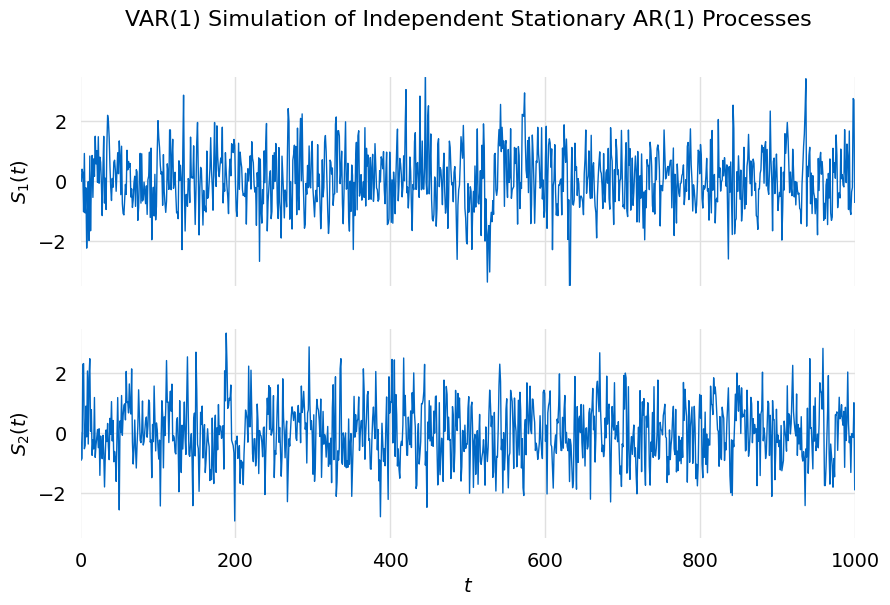

In [5]:
title = f"VAR(1) Simulation of Independent Stationary AR(1) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [6]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 09, Sep, 2023
Time:                     16:05:10
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                 -0.0601550
Nobs:                     4999.00    HQIC:                -0.0652354
Log likelihood:          -14010.6    FPE:                   0.934282
AIC:                   -0.0679769    Det(Omega_mle):        0.933162
--------------------------------------------------------------------
Results for equation S0
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.001083         0.013961           -0.078           0.938
L1.S0         0.248478         0.013717           18.115           0.000
L1.S1        -0.010485         0.013798           -0.760           0.447

Results for equation 

In [7]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": -0.0010826335373238846,
         "err": 0.013961156160355568,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "fdabe1ea-7569-4e4a-a44f-867198e42c83",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.007035311171611901,
         "err": 0.013844121398372716,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "fdabe1ea-7569-4e4a-a44f-867198e42c83",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 4,
   "_VAREst__params": [
      {
         "est": 0.24847822663332902,
         "err": 0.013716820742632675,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order"

### Coupled $\text{AR}(1)$

In [8]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.05],
                      [0.5, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [9]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

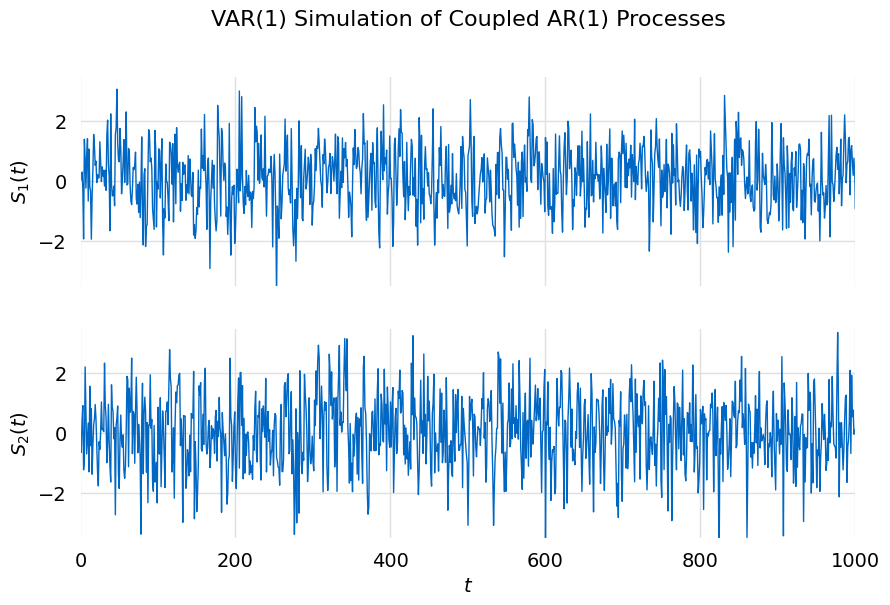

In [10]:
title = f"VAR(1) Simulation of Coupled AR(1) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [11]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 09, Sep, 2023
Time:                     16:05:10
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0121416
Nobs:                     4999.00    HQIC:                0.00706118
Log likelihood:          -14191.3    FPE:                    1.00433
AIC:                   0.00431968    Det(Omega_mle):         1.00312
--------------------------------------------------------------------
Results for equation S0
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.013883         0.014100            0.985           0.325
L1.S0         0.262046         0.013727           19.090           0.000
L1.S1         0.032882         0.012263            2.681           0.007

Results for equation 

In [12]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": 0.013882942463332786,
         "err": 0.014100221033245326,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "f938b95d-4608-4165-927c-8795c36063e2",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.006131485683606628,
         "err": 0.014215226029010163,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "f938b95d-4608-4165-927c-8795c36063e2",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 4,
   "_VAREst__params": [
      {
         "est": 0.2620464814404841,
         "err": 0.013726799808433787,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 1

### Coupled $\text{AR}(1)$ With Non Unit Normal Noise

In [13]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.05],
                      [0.5, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[2.0, 0.2],
                      [0.2, 2.0]])
npts=5000
nlag=1
var.compute_is_stationary(phi)

True

In [14]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

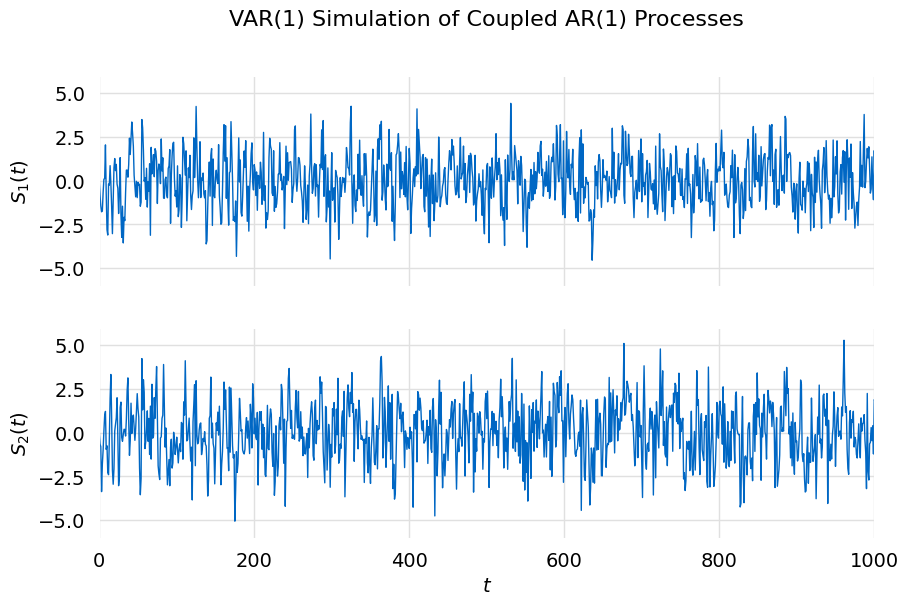

In [15]:
title = f"VAR(1) Simulation of Coupled AR(1) Processes"
comparison_plot(xt, title, ylim=(-6.0, 6.0))

In [16]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 09, Sep, 2023
Time:                     16:05:10
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    1.36002
Nobs:                     4999.00    HQIC:                   1.35494
Log likelihood:          -17560.4    FPE:                    3.86591
AIC:                      1.35220    Det(Omega_mle):         3.86127
--------------------------------------------------------------------
Results for equation S0
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.020510         0.019721            1.040           0.298
L1.S0         0.239457         0.013997           17.108           0.000
L1.S1         0.067853         0.012419            5.464           0.000

Results for equation 

In [17]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": 0.02050970426102065,
         "err": 0.019721356295380722,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "2f2c8bf0-d4fd-434c-95d2-53947f4a550f",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.011012490918263531,
         "err": 0.0200676730898922,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "2f2c8bf0-d4fd-434c-95d2-53947f4a550f",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 4,
   "_VAREst__params": [
      {
         "est": 0.23945720703281506,
         "err": 0.013996610266649574,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,


## $\text{VAR}(2)$ Simulations
### Uncoupled $\text{AR}(2)$

In [18]:
phi = numpy.array([
        numpy.matrix([[0.25, 0.0],
                      [0.0, 0.25]]),
        numpy.matrix([[0.5, 0.0],
                      [0.0, 0.5]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=2
var.compute_is_stationary(phi)

True

In [19]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

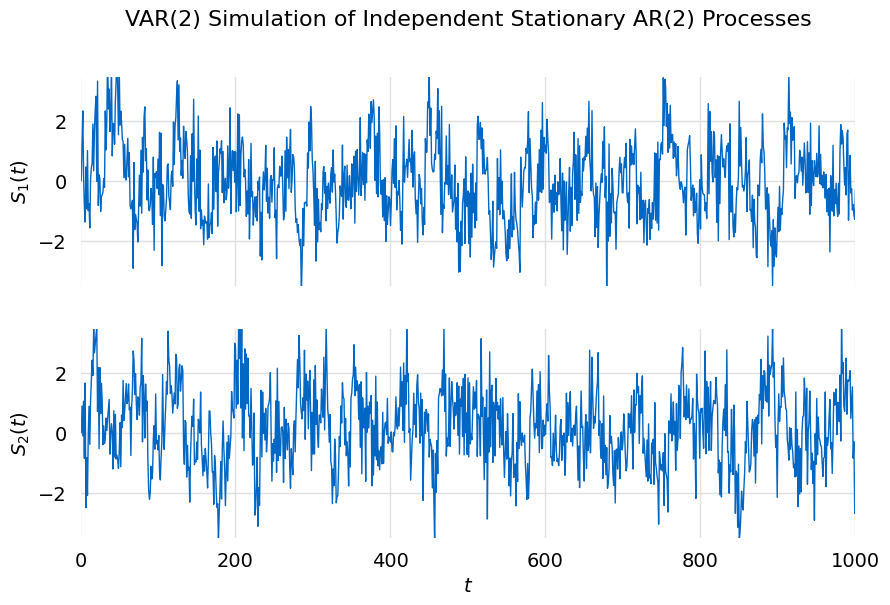

In [20]:
title = f"VAR(2) Simulation of Independent Stationary AR(2) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [21]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 09, Sep, 2023
Time:                     16:05:11
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0626712
Nobs:                     4998.00    HQIC:                 0.0542024
Log likelihood:          -14297.7    FPE:                    1.05088
AIC:                    0.0496324    Det(Omega_mle):         1.04879
--------------------------------------------------------------------
Results for equation S0
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const        -0.017055         0.014292           -1.193           0.233
L1.S0         0.248785         0.012298           20.229           0.000
L1.S1        -0.014420         0.012217           -1.180           0.238
L2.S0         0.495577

In [22]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": -0.01705463684555501,
         "err": 0.014292340887033562,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "d4879d69-12b0-4005-8676-af13d66f8643",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.00534988556244387,
         "err": 0.014392303144135725,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "d4879d69-12b0-4005-8676-af13d66f8643",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 8,
   "_VAREst__params": [
      {
         "est": 0.24878505690168695,
         "err": 0.012298200728996338,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,

### Coupled $\text{AR}(2)$

In [23]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.15],
                      [0.1, 0.1]]),
        numpy.matrix([[0.25, 0.3],
                      [0.2, 0.15]])])
mu = numpy.array([0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0],
                      [0.0, 1.0]])
npts=5000
nlag=2
var.compute_is_stationary(phi)

True

In [24]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

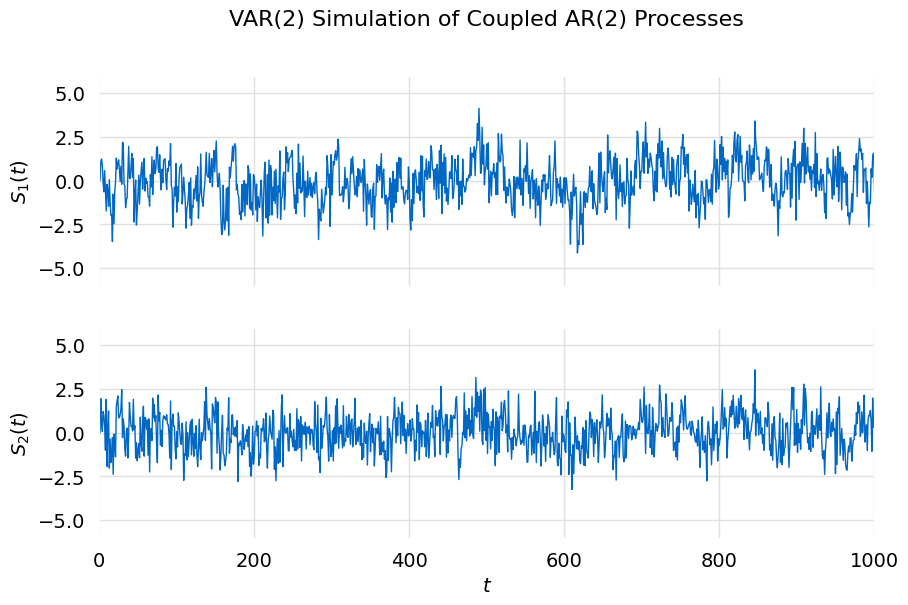

In [25]:
title = f"VAR(2) Simulation of Coupled AR(2) Processes"
comparison_plot(xt, title, ylim=(-6.0, 6.0))

In [26]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 09, Sep, 2023
Time:                     16:05:11
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                  0.0209229
Nobs:                     4998.00    HQIC:                 0.0124541
Log likelihood:          -14193.4    FPE:                    1.00792
AIC:                   0.00788411    Det(Omega_mle):         1.00590
--------------------------------------------------------------------
Results for equation S0
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.000880         0.014112            0.062           0.950
L1.S0         0.163604         0.012941           12.642           0.000
L1.S1         0.144266         0.013492           10.693           0.000
L2.S0         0.265180

In [27]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": 0.0008802113620317889,
         "err": 0.014112372448700504,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "cacae51f-a180-4a4c-9a9b-477b0f8445ab",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.007281439360552974,
         "err": 0.0142247204629064,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "cacae51f-a180-4a4c-9a9b-477b0f8445ab",
         "param_type": "VAR_CONST"
      }
   ],
   "_VAREst__order": 8,
   "_VAREst__params": [
      {
         "est": 0.16360435571004178,
         "err": 0.012940849972883278,
         "est_label": "$\\hat{Phi}_{i}$",
         "err_label": "$\\sigma^\\Phi_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,

## $\text{VAR}(3)$ Simulations
### Uncoupled $\text{AR}(3)$

In [28]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.0, 0.0],
                      [0.0, 0.15, 0.0],
                      [0.0, 0.0, 0.05]]),
        numpy.matrix([[0.05, 0.0, 0.0],
                      [0.0, 0.1, 0.0],
                      [0.0, 0.0, 0.05]]),
        numpy.matrix([[0.15, 0.0, 0.0],
                      [0.0, 0.15, 0.0],
                      [0.0, 0.0, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])
var.compute_is_stationary(phi)
npts=5000
nlag=3

In [29]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

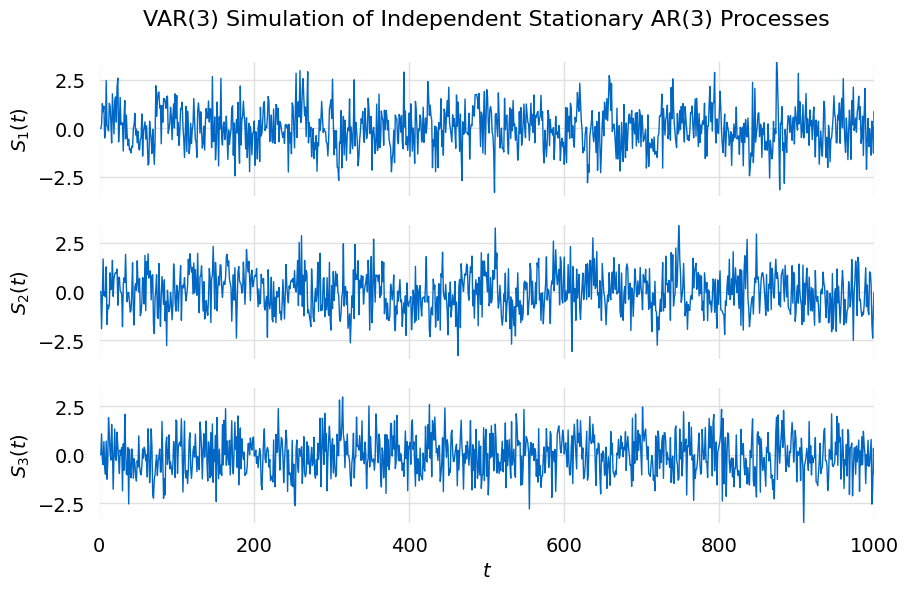

In [30]:
title = f"VAR(3) Simulation of Independent Stationary AR(3) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [31]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 09, Sep, 2023
Time:                     16:05:12
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  0.0748006
Nobs:                     4997.00    HQIC:                 0.0493900
Log likelihood:          -21330.4    FPE:                    1.03632
AIC:                    0.0356775    Det(Omega_mle):         1.03012
--------------------------------------------------------------------
Results for equation S0
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.001812         0.014262            0.127           0.899
L1.S0         0.158638         0.013968           11.357           0.000
L1.S1        -0.017407         0.014002           -1.243           0.214
L1.S2         0.020587

In [32]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": 0.0018115696988629279,
         "err": 0.014261799723598543,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "84a41e62-c79f-4fbf-8c19-3f1031fe30c1",
         "param_type": "VAR_CONST"
      },
      {
         "est": -0.009346295776682842,
         "err": 0.014227774567530299,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "84a41e62-c79f-4fbf-8c19-3f1031fe30c1",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.020012345219334187,
         "err": 0.014202794017927714,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 2,
         "order": 1,
         "est_id": "84a41e62-c79f-4fbf-8c19-3f1031fe30

### Coupled $\text{AR}(3)$

In [33]:
phi = numpy.array([
        numpy.matrix([[0.15, 0.1, 0.2],
                      [0.0, 0.15, 0.1],
                      [0.05, 0.025, 0.05]]),
        numpy.matrix([[0.015, 0.01, 0.0],
                      [0.1, 0.1, 0.05],
                      [0.1, 0.05, 0.05]]),
        numpy.matrix([[0.15, 0.05, 0.1],
                      [0.0, 0.15, 0.025],
                      [0.025, 0.15, 0.05]])])
mu = numpy.array([0.0, 0.0, 0.0])
omega = numpy.matrix([[1.0, 0.0, 0.0],
                      [0.0, 1.0, 0.0],
                      [0.0, 0.0, 1.0]])
npts=5000
nlag=11
var.compute_is_stationary(phi)


True

In [34]:
t, xt = var.create_source(phi, Ω=omega, μ=mu, npts=npts)

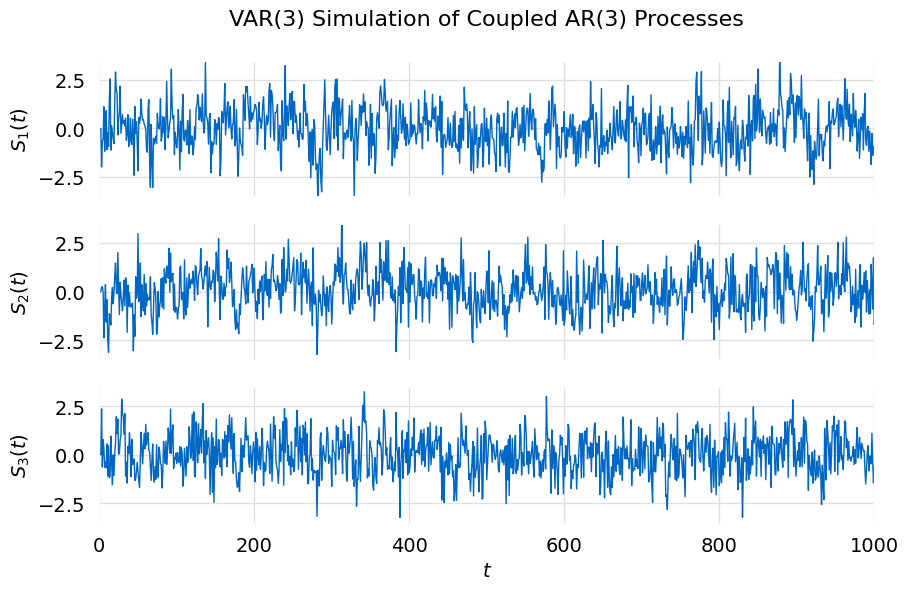

In [35]:
title = f"VAR(3) Simulation of Coupled AR(3) Processes"
comparison_plot(xt, title, ylim=(-3.5, 3.5))

In [36]:
result, result_model = var.compute_estimate(xt, maxlags=nlag)
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 09, Sep, 2023
Time:                     16:05:12
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   0.183852
Nobs:                     4989.00    HQIC:                 0.0973422
Log likelihood:          -21261.6    FPE:                    1.05196
AIC:                    0.0506529    Det(Omega_mle):         1.03074
--------------------------------------------------------------------
Results for equation S0
            coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------
const         -0.018909         0.014384           -1.315           0.189
L1.S0          0.176305         0.014191           12.423           0.000
L1.S1          0.122821         0.014332            8.570           0.000
L1.S2          0.

In [37]:
print(result_model.to_json(pretty=True))

{
   "_VAREst__est_model": "VAR",
   "_VAREst__const": [
      {
         "est": -0.01890940738951865,
         "err": 0.014384236125779694,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "585d7c42-cb64-4112-bb46-0cfd0ba0e1c5",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.020000800180702317,
         "err": 0.0142587481211861,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 1,
         "order": 1,
         "est_id": "585d7c42-cb64-4112-bb46-0cfd0ba0e1c5",
         "param_type": "VAR_CONST"
      },
      {
         "est": 0.01083913586309434,
         "err": 0.014280349725833539,
         "est_label": "$\\hat{M}_{i}$",
         "err_label": "$\\sigma^M_{i}$",
         "row": 0,
         "column": 2,
         "order": 1,
         "est_id": "585d7c42-cb64-4112-bb46-0cfd0ba0e1c5",
